<a href="https://colab.research.google.com/github/varshabantu/Data-Science-Tasks/blob/main/Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Analysing Ecommerce Sales drop**


**Company Scenario (Flipkart/amazon)**

We are seeing a drop in revenue find the reason and suggest actions.

In [ ]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load the data
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
products = pd.read_csv("products.csv")

In [ ]:
#merging the datasets
df = pd.merge(orders, customers, on="customer_id",how="inner")
df = pd.merge(df, products, on="product_id",how="inner")
df

,order_id,customer_id,product_id,order_date,city,quantity,customer_name,signup_date,product_name,category,price
0,1,101,201,2024-01-05,Hyderabad,1,Ravi,2023-11-10,Laptop,Electronics,70000
1,2,102,202,2024-01-06,Bangalore,2,Sneha,2023-12-01,Mobile,Electronics,20000
2,3,103,203,2024-01-10,Chennai,1,Amit,2023-12-15,Tablet,Electronics,15000
3,4,101,202,2024-02-12,Hyderabad,1,Ravi,2023-11-10,Mobile,Electronics,20000
4,5,104,204,2024-02-18,Bangalore,3,Pooja,2024-01-05,Shoes,Fashion,3000
5,6,105,201,2024-03-05,Chennai,1,Kiran,2024-01-20,Laptop,Electronics,70000
6,7,102,203,2024-03-15,Bangalore,1,Sneha,2023-12-01,Tablet,Electronics,15000
7,8,106,205,2024-04-02,Hyderabad,2,Arjun,2024-02-02,Watch,Fashion,5000
8,9,107,202,2024-04-10,Chennai,1,Divya,2024-02-15,Mobile,Electronics,20000
9,10,108,204,2024-04-18,Bangalore,2,Rahul,2024-03-01,Shoes,Fashion,3000


**EDA (Exploratary Data Analysis)**


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_id       20 non-null     int64 
 1   customer_id    20 non-null     int64 
 2   product_id     20 non-null     int64 
 3   order_date     20 non-null     object
 4   city           20 non-null     object
 5   quantity       20 non-null     int64 
 6   customer_name  20 non-null     object
 7   signup_date    20 non-null     object
 8   product_name   20 non-null     object
 9   category       20 non-null     object
 10  price          20 non-null     int64 
dtypes: int64(5), object(6)
memory usage: 1.8+ KB


In [ ]:
#Convert object into date tym format(signup_date)
#Converting date columns into datetime format
df["signup_date"] = pd.to_datetime(df["signup_date"])
df["order_date"] = pd.to_datetime(df["order_date"])
df

,order_id,customer_id,product_id,order_date,city,quantity,customer_name,signup_date,product_name,category,price
0,1,101,201,2024-01-05,Hyderabad,1,Ravi,2023-11-10,Laptop,Electronics,70000
1,2,102,202,2024-01-06,Bangalore,2,Sneha,2023-12-01,Mobile,Electronics,20000
2,3,103,203,2024-01-10,Chennai,1,Amit,2023-12-15,Tablet,Electronics,15000
3,4,101,202,2024-02-12,Hyderabad,1,Ravi,2023-11-10,Mobile,Electronics,20000
4,5,104,204,2024-02-18,Bangalore,3,Pooja,2024-01-05,Shoes,Fashion,3000
5,6,105,201,2024-03-05,Chennai,1,Kiran,2024-01-20,Laptop,Electronics,70000
6,7,102,203,2024-03-15,Bangalore,1,Sneha,2023-12-01,Tablet,Electronics,15000
7,8,106,205,2024-04-02,Hyderabad,2,Arjun,2024-02-02,Watch,Fashion,5000
8,9,107,202,2024-04-10,Chennai,1,Divya,2024-02-15,Mobile,Electronics,20000
9,10,108,204,2024-04-18,Bangalore,2,Rahul,2024-03-01,Shoes,Fashion,3000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       20 non-null     int64         
 1   customer_id    20 non-null     int64         
 2   product_id     20 non-null     int64         
 3   order_date     20 non-null     datetime64[ns]
 4   city           20 non-null     object        
 5   quantity       20 non-null     int64         
 6   customer_name  20 non-null     object        
 7   signup_date    20 non-null     datetime64[ns]
 8   product_name   20 non-null     object        
 9   category       20 non-null     object        
 10  price          20 non-null     int64         
dtypes: datetime64[ns](2), int64(5), object(4)
memory usage: 1.8+ KB


In [ ]:
#create revenue column
#Formula:  revenue = price*quantity
df["revenue"]= df["price"] * df["quantity"]
df

,order_id,customer_id,product_id,order_date,city,quantity,customer_name,signup_date,product_name,category,price,revenue
0,1,101,201,2024-01-05,Hyderabad,1,Ravi,2023-11-10,Laptop,Electronics,70000,70000
1,2,102,202,2024-01-06,Bangalore,2,Sneha,2023-12-01,Mobile,Electronics,20000,40000
2,3,103,203,2024-01-10,Chennai,1,Amit,2023-12-15,Tablet,Electronics,15000,15000
3,4,101,202,2024-02-12,Hyderabad,1,Ravi,2023-11-10,Mobile,Electronics,20000,20000
4,5,104,204,2024-02-18,Bangalore,3,Pooja,2024-01-05,Shoes,Fashion,3000,9000
5,6,105,201,2024-03-05,Chennai,1,Kiran,2024-01-20,Laptop,Electronics,70000,70000
6,7,102,203,2024-03-15,Bangalore,1,Sneha,2023-12-01,Tablet,Electronics,15000,15000
7,8,106,205,2024-04-02,Hyderabad,2,Arjun,2024-02-02,Watch,Fashion,5000,10000
8,9,107,202,2024-04-10,Chennai,1,Divya,2024-02-15,Mobile,Electronics,20000,20000
9,10,108,204,2024-04-18,Bangalore,2,Rahul,2024-03-01,Shoes,Fashion,3000,6000


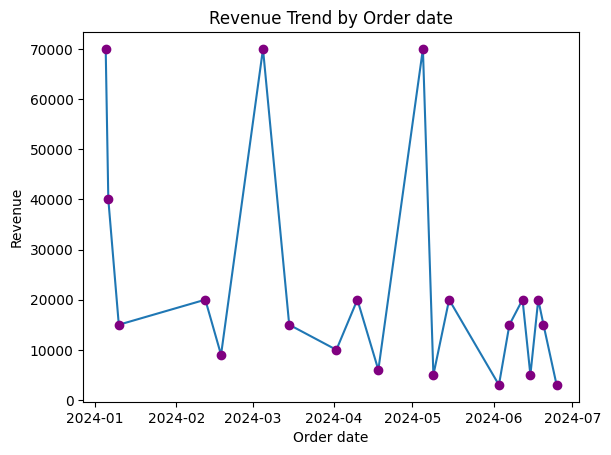

In [ ]:
#Find the Revenue trend based on order_date
revenue = df.groupby("order_date")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
plt.plot(revenue["order_date"],df["revenue"],marker="o",mfc="purple",mec="purple")
plt.xlabel("Order date")
plt.ylabel("Revenue")
plt.title("Revenue Trend by Order date")
plt.show()
#To understand which date the revenue is drop we use visualization.

**As per the analysis the revenue is very less in the last 2 months (mid may,june,july)**

In [ ]:
#Where exactly sales are droping in which city.
df["city"].unique()

array(['Hyderabad', 'Bangalore', 'Chennai'], dtype=object)

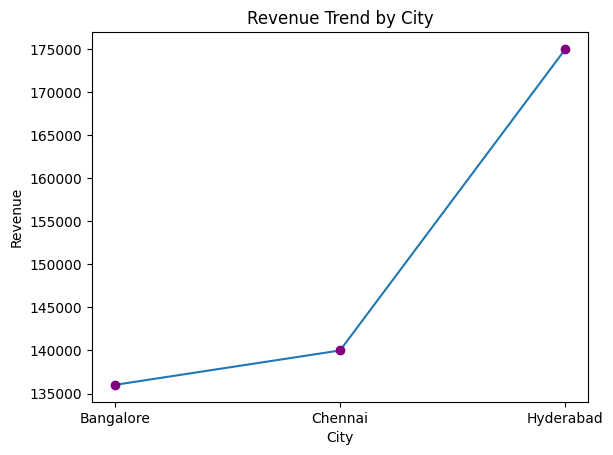

In [ ]:
# Revenue Trend by city
revenue = df.groupby("city")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
plt.plot(revenue["city"],revenue["revenue"],marker="o",mfc="purple",mec="purple")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Revenue Trend by City")
plt.show()

**Revenue is dropping in Banglore**

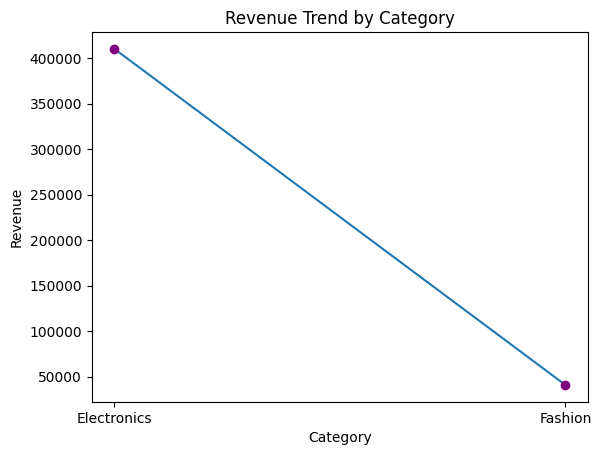

In [ ]:
# Revenue Trend by category
revenue = df.groupby("category")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
plt.plot(revenue["category"],revenue["revenue"],marker="o",mfc="purple",mec="purple")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.title("Revenue Trend by Category")
plt.show()

**In Fashion category revenue got dropped**

In [ ]:
#Count customers based on order_id
customers = df.groupby("customer_id")["order_id"].count()
customers

,order_id
customer_id,
101,3
102,2
103,2
104,2
105,1
106,1
107,1
108,1
109,1


**Most of the customers are ordering less**

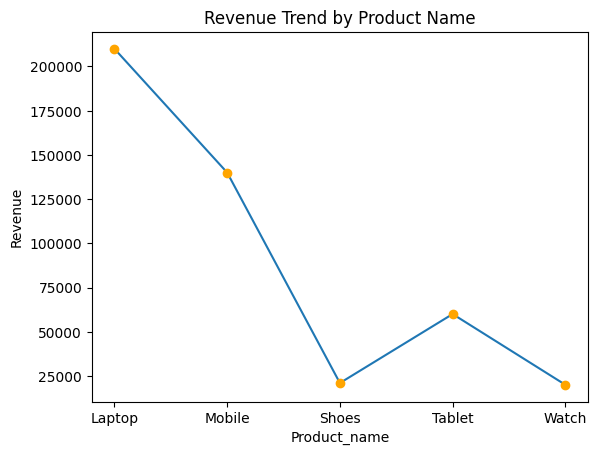

In [ ]:
# Which product having least revenue
revenue = df.groupby("product_name")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
plt.plot(revenue["product_name"],revenue["revenue"],marker="o",mfc="orange",mec="orange")
plt.xlabel("Product_name")
plt.ylabel("Revenue")
plt.title("Revenue Trend by Product Name")
plt.show()

**Revenue is very less for shoes and watch**

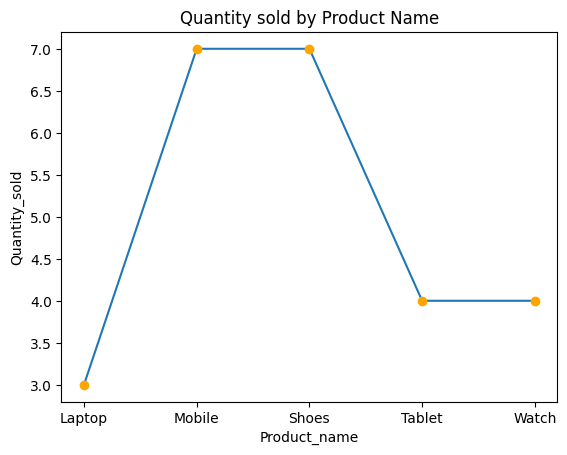

In [ ]:
Quantity_sold = df.groupby("product_name")["quantity"].sum()
Quantity_sold = pd.DataFrame(Quantity_sold).reset_index()
plt.plot(Quantity_sold["product_name"],Quantity_sold["quantity"],marker="o",mfc="orange",mec="orange")
plt.xlabel("Product_name")
plt.ylabel("Quantity_sold")
plt.title("Quantity sold by Product Name")
plt.show()

# Insights:

1) Revenue got dropped in last two months (june,july)

2) Banglore Contributed more in revenue drop

3) Fashion Category recorded less revenue

4) Repeated customers order less

5) Shoes and Watch sales declined significantly.

# Recommendations:

1) Marketing should be done in banglore.

2) Provide discounts for shoe and watch.

3) Coupens, discounts, loyalty programs for repeated customers.

In [ ]:
df

,order_id,customer_id,product_id,order_date,city,quantity,customer_name,signup_date,product_name,category,price,revenue
0,1,101,201,2024-01-05,Hyderabad,1,Ravi,2023-11-10,Laptop,Electronics,70000,70000
1,2,102,202,2024-01-06,Bangalore,2,Sneha,2023-12-01,Mobile,Electronics,20000,40000
2,3,103,203,2024-01-10,Chennai,1,Amit,2023-12-15,Tablet,Electronics,15000,15000
3,4,101,202,2024-02-12,Hyderabad,1,Ravi,2023-11-10,Mobile,Electronics,20000,20000
4,5,104,204,2024-02-18,Bangalore,3,Pooja,2024-01-05,Shoes,Fashion,3000,9000
5,6,105,201,2024-03-05,Chennai,1,Kiran,2024-01-20,Laptop,Electronics,70000,70000
6,7,102,203,2024-03-15,Bangalore,1,Sneha,2023-12-01,Tablet,Electronics,15000,15000
7,8,106,205,2024-04-02,Hyderabad,2,Arjun,2024-02-02,Watch,Fashion,5000,10000
8,9,107,202,2024-04-10,Chennai,1,Divya,2024-02-15,Mobile,Electronics,20000,20000
9,10,108,204,2024-04-18,Bangalore,2,Rahul,2024-03-01,Shoes,Fashion,3000,6000
